In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# Cinema Audience Forecasting Challenge

**Objective:** Predict daily theatre audience counts across multiple locations using historical data and machine learning techniques.

---

## Project Overview
The goal of this project is to build an end-to-end machine learning pipeline that forecasts daily audience attendance for cinemas. This includes:

- **Data Collection & Preprocessing:** Handling missing values, feature engineering, and data transformation.
- **Exploratory Data Analysis (EDA):** Understanding trends, seasonality, and audience patterns.
- **Feature Engineering:** Creating lag, rolling, and categorical features relevant for forecasting.
- **Modeling:** Training and tuning regression models to predict audience counts with R² evaluation metrics to access the model performance.
- **Hyperparameter Tuning:** Performed hyperparameter tuning for the best model
- **Submission & Testing:** Generating a submission file for the test dataset and validating it




## Section 1: Import Libraries & Load Data
In this section, I import all necessary libraries required for the end-to-end machine learning pipeline and load the datasets with appropriate labeling for subsequent processing and analysis.

In [2]:
# IMPORT LIBRARIES AND LOADING DATAS
#------------------------------------
import os
from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Evaluation metrics
from sklearn.metrics import r2_score

# Suppress unnecessary warnings
warnings.filterwarnings("ignore")

# Display and plotting configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("All required libraries were imported successfully.")

#DATA LOADING
#-------------

BASE_PATH = "/kaggle/input/Cinema_Audience_Forecasting_challenge"

cinepos_theaters = pd.read_csv(f"{BASE_PATH}/cinePOS_theaters/cinePOS_theaters.csv")
booknow_theaters = pd.read_csv(f"{BASE_PATH}/booknow_theaters/booknow_theaters.csv")
theater_relation = pd.read_csv(f"{BASE_PATH}/movie_theater_id_relation/movie_theater_id_relation.csv")
cinepos_booking = pd.read_csv(f"{BASE_PATH}/cinePOS_booking/cinePOS_booking.csv")
booknow_booking = pd.read_csv(f"{BASE_PATH}/booknow_booking/booknow_booking.csv")
booknow_visits = pd.read_csv(f"{BASE_PATH}/booknow_visits/booknow_visits.csv")
date_info = pd.read_csv(f"{BASE_PATH}/date_info/date_info.csv")
sample_submission = pd.read_csv(f"{BASE_PATH}/sample_submission/sample_submission.csv")

print("All csv files uploaded successfully")


All required libraries were imported successfully.
All csv files uploaded successfully


### Exploratory Data Analysis (EDA)

In this section, I explore the datasets to understand their structure, identify missing values, analyze the target variable, inspect temporal patterns, and examine theater and booking behaviors.

**3.1 Quick Overview**

In this section, I perform an initial examination of all relevant datasets to understand their structure, completeness, and basic characteristics. This helps in identifying missing values, understanding the scale of data, and getting a preliminary sense of the features available for modeling.

**Datasets Overview:**

- **BookNow Visits (TARGET):** Contains the daily audience counts that serve as the target variable for forecasting.
- **BookNow Theaters:** Metadata about theaters available on the BookNow platform.
- **CinePOS Theaters:** Metadata for theaters tracked via the CinePOS system.
- **Theater Relation:** Mapping information between different theater IDs across systems.
- **BookNow Booking:** Historical booking transactions from BookNow.
- **CinePOS Booking:** Historical booking transactions from CinePOS.
- **Date Info:** Calendar and date-related information useful for temporal feature engineering.

**Actions performed:**
- Checked the **number of rows and columns** for each dataset.
- Identified **missing values** in each column.
- Counted **unique values** per column to understand categorical and identifier distributions.
- Displayed the **first few rows** to get a sense of the data format and sample values.

This step is critical for guiding preprocessing, feature engineering, and ensuring data quality before modeling.

In [3]:
# Quick summary of the individual Data sets
datasets = {
    "BookNow Visits (TARGET)": booknow_visits,
    "BookNow Theaters": booknow_theaters,
    "CinePOS Theaters": cinepos_theaters,
    "Theater Relation": theater_relation,
    "BookNow Booking": booknow_booking,
    "CinePOS Booking": cinepos_booking,
    "Date Info": date_info
}

for name, df in datasets.items():
    print(f"\n{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("Unique values per column:\n", df.nunique())
    print(df.head(2))



BookNow Visits (TARGET): 214,046 rows × 3 columns
Missing values:
 Series([], dtype: int64)
Unique values per column:
 book_theater_id    826
show_date          424
audience_count     191
dtype: int64
  book_theater_id   show_date  audience_count
0      book_00001  2023-01-13              50
1      book_00001  2023-01-14              64

BookNow Theaters: 829 rows × 5 columns
Missing values:
 book_theater_id    515
dtype: int64
Unique values per column:
 book_theater_id    314
theater_type         4
theater_area       103
latitude           108
longitude          108
dtype: int64
  book_theater_id theater_type theater_area  latitude  longitude
0      book_00093        Drama     Area_001     22.62      78.11
1      book_00078        Drama     Area_001     22.62      78.11

CinePOS Theaters: 4,690 rows × 5 columns
Missing values:
 latitude     3861
longitude    3861
dtype: int64
Unique values per column:
 cine_theater_id    4690
theater_type          3
theater_area        119
latitude  

### EDA (Continue)
**3.2 Target_Variable Analysis**

In this section, we focus on analyzing the target variable **`audience_count`**, which represents the daily audience visits per theatre. Understanding its distribution, scale, and presence of outliers is essential before model training.

### **Statistical Summary**
A descriptive summary of `audience_count` provides insights into its central tendency, spread, and overall distribution. This helps identify skewness, variance, and potential anomalies that may affect modeling.

### **Distribution Analysis**
Two visualizations are used to understand the distribution:

- **Raw Distribution (Histogram):**  
  Shows the overall spread of audience counts. The distribution is typically right-skewed due to occasional high-demand days (weekends, holidays, festivals, major movie releases).

- **Log-Transformed Distribution:**  
  Applying `log1p` reduces skewness and brings the distribution closer to normality, which can improve model stability and performance for certain algorithms.

### **Outlier Detection**
Using the IQR rule, outliers are detected as data points beyond **1.5 × IQR** from the quartiles.  
The analysis reports:
- **Number of outliers**
- **Percentage of outliers relative to dataset size**

This exploration forms the foundation for subsequent preprocessing and model development.


count   214046.00
mean        41.62
std         32.83
min          2.00
25%         18.00
50%         34.00
75%         58.00
max       1350.00
Name: audience_count, dtype: float64


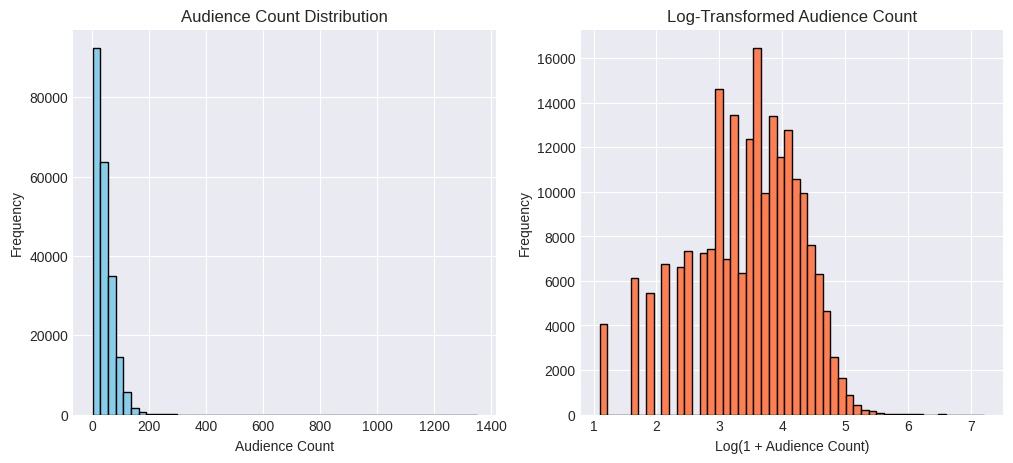

Outliers: 5589 (2.61%)


In [4]:
# Target: audience_count
target = booknow_visits['audience_count']

# Statistical summary
print(target.describe())

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
axes[0].hist(target, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Audience Count Distribution')
axes[0].set_xlabel('Audience Count')
axes[0].set_ylabel('Frequency')

# Log-transformed histogram
axes[1].hist(np.log1p(target), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Log-Transformed Audience Count')
axes[1].set_xlabel('Log(1 + Audience Count)')
axes[1].set_ylabel('Frequency')

plt.show()

# Outlier detection
Q1, Q3 = target.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = target[(target < Q1 - 1.5*IQR) | (target > Q3 + 1.5*IQR)]
print(f"Outliers: {len(outliers)} ({len(outliers)/len(target)*100:.2f}%)")


- The raw `audience_count` distribution is **strongly right-skewed**, with most values under 100 and a long tail of high-attendance days.
- This skewness is consistent with the statistical summary, where the **median < mean**.
- Occasional spikes (e.g., festivals, blockbuster releases, weekends) create uneven audience patterns.
- Applying a **log1p transformation** results in a more balanced, bell-shaped distribution:
  - Compresses extreme values
  - Spreads out lower counts
  - Makes the data more model-friendly
- Outlier analysis detected **5,589 outliers (2.61%)**, mostly representing legitimate high-demand days.
- These spikes are meaningful signals and should be **kept**, not removed.
- Together, the raw and log-transformed views offer a clearer understanding of audience behavior and help guide feature engineering and modeling decisions.


## EDA (Continue)

**3.3 Temporal Analysis**

* Merged datasets
    * Converted show_date to datetime in both dataframes
    * Merged booknow_visits with date_info using a left join on show_date.
* Daily Trend
    * Grouped by show_date and computed average audience count.
    * Plotted a daily line chart of audience trends.
* Day-of-Week Trend
    * Grouped by day_of_week and calculated average audience.
    * Reordered days Monday → Sunday.
    * Plotted a bar chart showing audience distribution across weekdays.

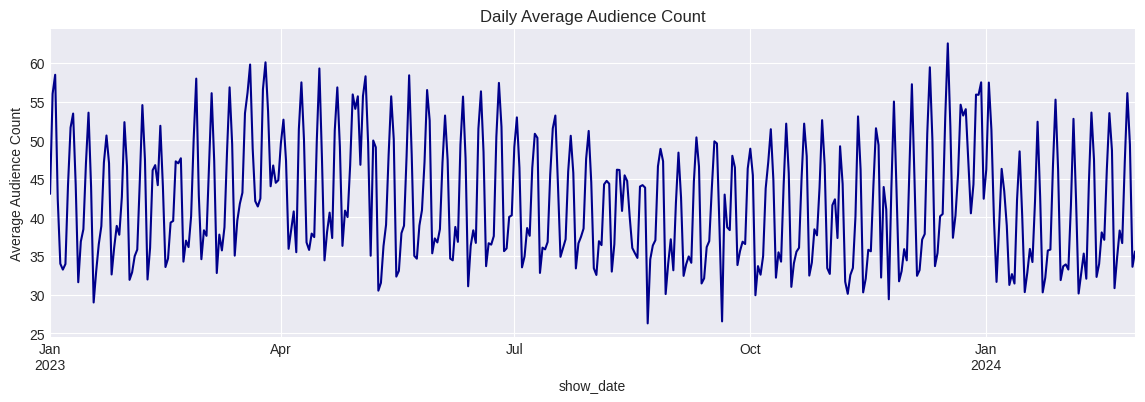

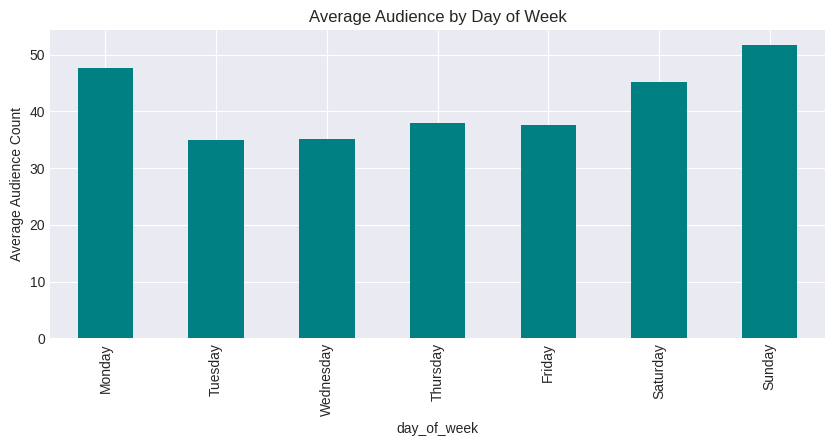

In [5]:
# Merge visits with date info
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
date_info['show_date'] = pd.to_datetime(date_info['show_date'])
temporal_df = booknow_visits.merge(date_info, on='show_date', how='left')

# Daily trend
daily_avg = temporal_df.groupby('show_date')['audience_count'].mean()
daily_avg.plot(figsize=(14,4), color='darkblue', title='Daily Average Audience Count')
plt.ylabel('Average Audience Count')
plt.show()

# Day of week trend
dow_avg = temporal_df.groupby('day_of_week')['audience_count'].mean()
dow_avg.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).plot(
    kind='bar', figsize=(10,4), color='teal', title='Average Audience by Day of Week'
)
plt.ylabel('Average Audience Count')
plt.show()


* **Temporal data insights:**

* Daily average audience count shows a clear seasonal pattern throughout the year.
* Peaks in April–May likely correspond to the summer vacation for kids.
* Drop from July to October aligns with the monsoon season in Madhya Pradesh.
* December dip appears to be due to the December break.
* Weekends (Saturday, Sunday) show consistently higher audience counts.

## EDA (Continue)
**3.4 Theater-Level Analysis**

- Audience Preferences by Theater Type:  
  Merged `booknow_theaters` with `booknow_visits` to analyze the influence of theater type on average audience count and identify overall patterns in audience behavior.

- Audience Preferences by Theater Area:
  Analyzed theater areas to determine the best-performing locations in terms of average audience engagement.

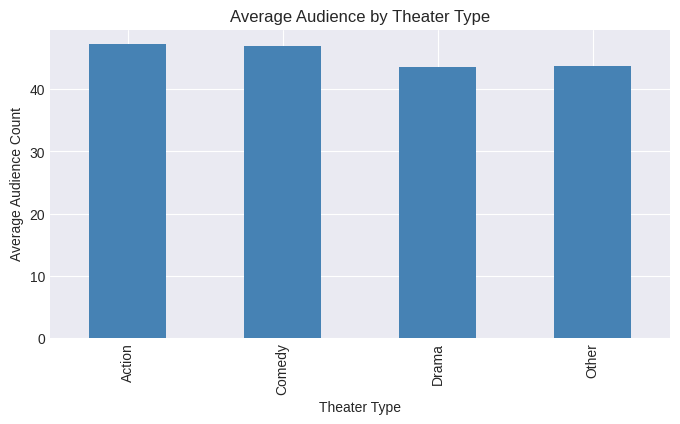

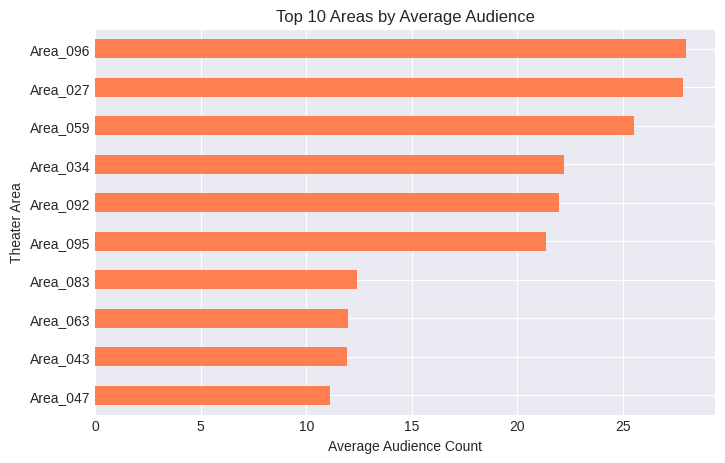

In [6]:
# Merge with theater info
theater_df = temporal_df.merge(booknow_theaters, on='book_theater_id', how='left')

# Average audience by theater type
if 'theater_type' in theater_df.columns:
    theater_type_stats = theater_df.groupby('theater_type')['audience_count'].mean()
    theater_type_stats.plot(kind='bar', figsize=(8,4), color='steelblue', title='Average Audience by Theater Type')
    plt.xlabel('Theater Type')                      
    plt.ylabel('Average Audience Count')   
    plt.show()
    
    # Top 10 areas by audience
    area_stats = theater_df.groupby('theater_area')['audience_count'].mean().sort_values(ascending=True).head(10)
    area_stats.plot(kind='barh', figsize=(8,5), color='coral', title='Top 10 Areas by Average Audience')
    plt.xlabel('Average Audience Count')       
    plt.ylabel('Theater Area')     
    plt.show()


## EDA (Continue)

**3.5 Booking Pattern Analysis**

**Online Bookings**
- Analyzed bookings made through the online platform.
- Lead Time:Calculated as the gap between booking date and show date.  
- Average Lead Time:Computed to understand how far in advance people book.  
- Observed that some bookings are made ~9days in advance, indicating early planning by certain users.  
- Visualized the distribution of lead times and the number of tickets per booking.

**POS Bookings**
- Analyzed transactions made at the point-of-sale (counter).  
- Most tickets are purchased on the same day or at the last minute, reflecting immediate purchase behavior.  
- Total tickets sold and number of POS transactions were summarized to compare volume against online bookings.

Total Online Bookings: 68,336
Total Tickets Booked Online: 302,442
Average Lead Time: 8.73 days

Total POS Transactions: 1,641,966
Total Tickets Sold at POS: 8,189,051


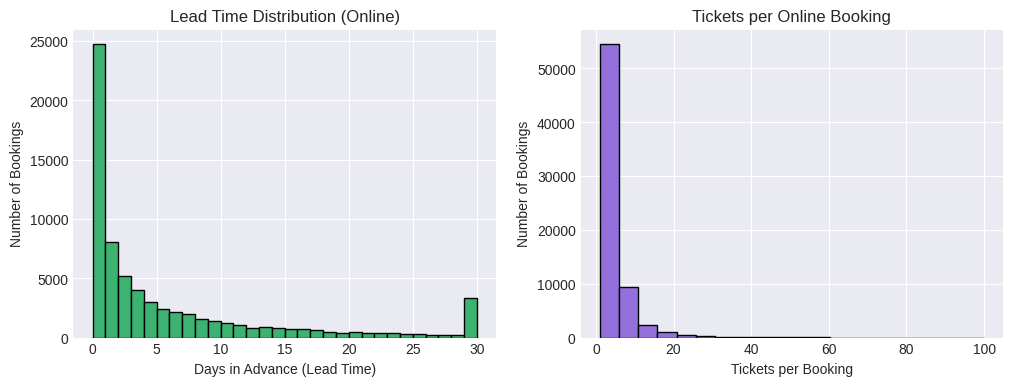

In [7]:
# Online bookings
online_df = booknow_booking.copy()
online_df['show_datetime'] = pd.to_datetime(online_df['show_datetime'])
online_df['booking_datetime'] = pd.to_datetime(online_df['booking_datetime'])
online_df['lead_days'] = (online_df['show_datetime'] - online_df['booking_datetime']).dt.days

print(f"Total Online Bookings: {len(online_df):,}")
print(f"Total Tickets Booked Online: {online_df['tickets_booked'].sum():,}")
print(f"Average Lead Time: {online_df['lead_days'].mean():.2f} days")

# POS bookings
pos_df = cinepos_booking.copy()
print(f"\nTotal POS Transactions: {len(pos_df):,}")
print(f"Total Tickets Sold at POS: {pos_df['tickets_sold'].sum():,}")

# Visualize lead time and tickets
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(online_df['lead_days'].clip(0,30), bins=30, color='mediumseagreen', edgecolor='black')
axes[0].set_title('Lead Time Distribution (Online)')
axes[0].set_xlabel('Days in Advance (Lead Time)')
axes[0].set_ylabel('Number of Bookings')

axes[1].hist(online_df['tickets_booked'], bins=20, color='mediumpurple', edgecolor='black')
axes[1].set_title('Tickets per Online Booking')
axes[1].set_xlabel('Tickets per Booking')
axes[1].set_ylabel('Number of Bookings')
plt.show()


## 4.Data Cleaning & Preprocessing

This section focuses on cleaning the datasets to ensure consistency, handle missing values, and prepare the data for analysis and modeling.
- Cleaned BookNow Theaters:
    - Removed rows with missing theater IDs (can't identify them)
    - Filled missing theater types with 'Unknown'
    - Filled missing areas with 'Unknown'
- Cleaned CinePOS Theaters:
    - Dropped latitude/longitude columns (too many missing values)
    - Cleaned Other Datasets:
- Converted date columns to proper datetime format
- Ensured consistency across all datasets

In [8]:
# DATA CLEANING
#----------------

booknow_theaters_clean = booknow_theaters.copy()

# Remove rows with missing theater ID

booknow_theaters_clean = booknow_theaters_clean.dropna(subset=['book_theater_id'])

# Fill missing theater type and area

booknow_theaters_clean['theater_type'] = booknow_theaters_clean['theater_type'].fillna('Unknown')
booknow_theaters_clean['theater_area'] = booknow_theaters_clean['theater_area'].fillna('Unknown')

cinepos_theaters_clean = cinepos_theaters.copy()

# Drop latitude/longitude due to missing values
if 'latitude' in cinepos_theaters_clean.columns:
    cinepos_theaters_clean = cinepos_theaters_clean.drop(columns=['latitude', 'longitude'])

# Rest of the CSV into clean variable
theater_relation_clean = theater_relation.copy()
booknow_visits_clean = booknow_visits.copy()
date_info_clean = date_info.copy()
date_info_clean['show_date'] = pd.to_datetime(date_info_clean['show_date'])
cinepos_booking_clean = cinepos_booking.copy()
booknow_booking_clean = booknow_booking.copy()

print ('Data cleaning is done successfully')
print(f"Theater Relation: {len(theater_relation_clean)} rows")
print(f"BookNow Visits: {len(booknow_visits_clean)} rows")
print(f"Date Info: {len(date_info_clean)} rows")
print(f"CinePOS Booking: {len(cinepos_booking_clean)} rows")
print(f"BookNow Booking: {len(booknow_booking_clean)} rows")

Data cleaning is done successfully
Theater Relation: 150 rows
BookNow Visits: 214046 rows
Date Info: 547 rows
CinePOS Booking: 1641966 rows
BookNow Booking: 68336 rows


## 5. Feature Engineering

**5.1 Base Features**
Started with the visits data (target variable) and merged additional information:
- Date information:Holidays, day of week, etc.  
- Theater information:Theater type, area, and other metadata.
  
**5.2 Date-Based Features**
Extracted useful time-related features:
- Year, Month, Day:Basic temporal markers  
- Week of Year:Week number (1–52)  
- Quarter:Q1, Q2, Q3, Q4 (seasonal patterns)  
- Is Weekend:Binary flag (1 if Saturday/Sunday, 0 otherwise)  
- Season:Winter, Summer & Monsoon.
  
**5.3 Theater Missing Info Flag**
Created a flag to track missing theater information:
- is_theater_info_missing:1 if theater info is missing, 0 otherwise  
- Missing theater type and area filled as "Unknown"  
- Latitude and longitude dropped due to excessive missing values
  
**5.4 Online Booking Features**
Aggregated online bookings per theater per day:
- Total online tickets:Number of tickets booked online  
- Online booking count:Number of transactions  
- Average lead days:Average days in advance people book  
- Max/Min lead days:Earliest and latest bookings


**5.5 POS (Counter) Booking Features**
Aggregated POS bookings similarly:
- Total POS tickets:Tickets sold at counters  
- POS transaction count:Number of transactions  
- Average tickets per transaction:Average group size
  
**5.6 Combined Booking Features**
Created combined metrics across channels:
- Total tickets all channels:Online + POS  
- Online/POS ratio:Relative preference for online vs counter bookings
  
**5.7 Lag Features (Time Series)**
- audience_lag_7:Audience 7 days ago  
- audience_lag_14:Audience 14 days ago  
- audience_lag_21:Audience 21 days ago  
- audience_lag_28:Audience 28 days ago

**5.8 Rolling Window Features**
Created moving average and variability features:
- 7-day, 14-day, 28-day rolling mean:Trend of audience over past days  
- 7-day, 14-day, 28-day rolling std:Variation in audience over past days  

**5.9 Theater-Level Aggregations**
Aggregated theater-level statistics:
- Theater average audience:Typical popularity of theater  
- Theater std audience:How variable attendance is  
- Theater median audience:Typical audience size  
- Theater total shows:Number of shows conducted

**5.10 Fill Missing Values**
Handled missing data after feature creation:

- Booking features: Fill missing with 0 (no bookings = 0)  
- Lag and rolling features:Fill missing with median (typical value)  
- Theater stats: Fill missing with mean (average value)  

**Result:** A master dataset with a comprehensive set of features ready for modeling.


In [9]:
# FEATURE ENGINEERING
#---------------------

# 5.1: Create Base Feature Set
#...............................

master_df = booknow_visits_clean.copy()
master_df['show_date'] = pd.to_datetime(master_df['show_date'])
# Merge with date info (holidays, day of week, etc.)
master_df = master_df.merge(date_info_clean, on='show_date', how='left')
master_df = master_df.merge(booknow_theaters_clean, on='book_theater_id', how='left')
print ('created base feature set')

# 5.2: Date-Based Features
#...........................

# Extract year, month, day, week, quarter
master_df['year'] = master_df['show_date'].dt.year
master_df['month'] = master_df['show_date'].dt.month
master_df['day'] = master_df['show_date'].dt.day
master_df['week_of_year'] = master_df['show_date'].dt.isocalendar().week.astype(int)
master_df['day_of_month'] = master_df['show_date'].dt.day
master_df['quarter'] = master_df['show_date'].dt.quarter

# Flag weekends
master_df['is_weekend'] = master_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Add seasons based on months
master_df['season'] = master_df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Mansoon', 7: 'Mansoon', 8: 'Mansoon',
    9: 'Mansoon', 10: 'Winter', 11: 'Winter'
})

print('created date based features')

# 5.3: Theater Missing Info Flag
#..................................

# Flag missing theater info
master_df['is_theater_info_missing'] = master_df['theater_type'].isnull().astype(int)

# Fill missing theater type and area
master_df['theater_type'] = master_df['theater_type'].fillna('Unknown')
master_df['theater_area'] = master_df['theater_area'].fillna('Unknown')

# Drop latitude/longitude as too many values are missing
if 'latitude' in master_df.columns:
    master_df = master_df.drop(columns=['latitude', 'longitude'])

print('flaged missing theaters')

# 5.4: Online Booking Features
# ....................................

online = booknow_booking_clean.copy()
online['show_datetime'] = pd.to_datetime(online['show_datetime'])
online['booking_datetime'] = pd.to_datetime(online['booking_datetime'])
online['show_date'] = pd.to_datetime(online['show_datetime'].dt.date)

# Calculate booking lead time in days
online['booking_lead_days'] = (online['show_datetime'] - online['booking_datetime']).dt.total_seconds() / (24*3600)

# Aggregate online booking features per theater per day
online_features = online.groupby(['book_theater_id', 'show_date']).agg(
    total_online_tickets=('tickets_booked','sum'),
    online_booking_count=('tickets_booked','count'),
    avg_online_lead_days=('booking_lead_days','mean'),
    max_online_lead_days=('booking_lead_days','max'),
    min_online_lead_days=('booking_lead_days','min')
).reset_index()

# Merge back to master dataset
master_df = master_df.merge(online_features, on=['book_theater_id','show_date'], how='left')

print('created online booking features')

# 5.5: POS (On-site) Booking Features
# .........................................

pos = cinepos_booking_clean.copy()
pos['show_datetime'] = pd.to_datetime(pos['show_datetime'])
pos['show_date'] = pd.to_datetime(pos['show_datetime'].dt.date)

# Map POS theaters to BookNow theater IDs
pos_linked = pos.merge(theater_relation_clean, on='cine_theater_id', how='inner')

# Aggregate POS booking features
pos_features = pos_linked.groupby(['book_theater_id','show_date']).agg(
    total_pos_tickets=('tickets_sold','sum'),
    pos_transaction_count=('tickets_sold','count'),
    avg_pos_tickets_per_transaction=('tickets_sold','mean')
).reset_index()

# Merge back to master
master_df = master_df.merge(pos_features, on=['book_theater_id','show_date'], how='left')

print('created POS booking features')

# 5.6: Combined Booking Features
# ......................................

# Total tickets across all channels
master_df['total_tickets_all_channels'] = master_df['total_online_tickets'].fillna(0) + master_df['total_pos_tickets'].fillna(0)

# Ratio of online to POS tickets
master_df['online_pos_ratio'] = np.where(
    master_df['total_pos_tickets'].fillna(0) > 0,
    master_df['total_online_tickets'].fillna(0) / master_df['total_pos_tickets'].fillna(1),
    0
)

print('created combined booking features')

# 5.7: Lag Features (Time Series)
# .......................................

# Sort by theater and date
master_df = master_df.sort_values(['book_theater_id','show_date']).reset_index(drop=True)

# Create lagged audience counts
lag_periods = [7, 14, 21, 28]  # Weekly lags
for lag in lag_periods:
    master_df[f'audience_lag_{lag}'] = master_df.groupby('book_theater_id')['audience_count'].shift(lag)

# 5.8: Rolling Window Features
# ..................................


# Rolling mean and std
windows = [7, 14, 28]
for window in windows:
    master_df[f'audience_rolling_mean_{window}'] = (
        master_df.groupby('book_theater_id')['audience_count']
        .shift(1)
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    master_df[f'audience_rolling_std_{window}'] = (
        master_df.groupby('book_theater_id')['audience_count']
        .shift(1)
        .rolling(window=window, min_periods=1)
        .std()
        .reset_index(level=0, drop=True)
    )

print('created lag and rolling features')

# 5.9: Theater-Level Aggregations
# ...........................................

# Aggregate audience stats per theater
theater_stats = master_df.groupby('book_theater_id').agg(
    theater_avg_audience=('audience_count','mean'),
    theater_std_audience=('audience_count','std'),
    theater_median_audience=('audience_count','median'),
    theater_total_shows=('audience_count','count')
).reset_index()

# Merge back to master
master_df = master_df.merge(theater_stats, on='book_theater_id', how='left')


# 5.10: Fill Missing Values
# ............................................

# Booking features -> fill missing with 0
booking_cols = [col for col in master_df.columns if 'online' in col or 'pos' in col or 'tickets' in col]
master_df[booking_cols] = master_df[booking_cols].fillna(0)

# Lag and rolling features -> fill missing with median
lag_cols = [col for col in master_df.columns if 'lag' in col or 'rolling' in col]
for col in lag_cols:
    master_df[col] = master_df[col].fillna(master_df[col].median())

# Theater stats -> fill missing with mean
theater_stat_cols = ['theater_avg_audience', 'theater_std_audience', 'theater_median_audience']
for col in theater_stat_cols:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(master_df[col].mean())

master_df['theater_total_shows'] = master_df['theater_total_shows'].fillna(0)


print(f"Final master dataset shape: {master_df.shape}")
print(f"Total features created: {master_df.shape[1] - 1} (excluding target)")


created base feature set
created date based features
flaged missing theaters
created online booking features
created POS booking features
created combined booking features
created lag and rolling features
Final master dataset shape: (214046, 39)
Total features created: 38 (excluding target)


## 6. Train-Validation Split (Time-Based)

For time series modeling, random splits are unsuitable as they can cause data leakage, where the training data might include information from the future. This can lead to misleadingly high validation scores, but poor real-world performance. A time-based split addresses this by using all data before a cutoff date for training and all data after for validation, effectively simulating real-world deployment where the future is predicted using past information.

**Implementation Steps**

1. **Sort data by date** and create a temporary `split_date` column.  
2. **Define validation period** as the last 2 months; everything before is training.  
   - Split ratio: approximately 80% training, 20% validation.  
3. **Split the dataset** into `train_data` and `val_data`.  
4. **Drop temporary columns** used for splitting.  
5. **Separate features and target:**  
   - Features: All columns except `audience_count` and `book_theater_id`.  
   - Target: `audience_count`.  
6. **Encode categorical variables** using `LabelEncoder`:
   - Converts text to numbers (e.g., `"Winter" → 0`, `"Spring" → 1`).  
   - Handles unseen categories in validation by mapping them to `"Unknown"`.  
7. **Final datasets for modeling:**  
   - `X_train`, `y_train` → Training features and target  
   - `X_val`, `y_val` → Validation features and target


In [10]:

# Step 1: Create a temporary datetime column for splitting
master_df['split_date'] = pd.to_datetime(master_df[['year', 'month', 'day']])

# Step 2: Determine validation period (last 2 months)
max_date = master_df['split_date'].max()
min_date = master_df['split_date'].min()
validation_start = max_date - pd.DateOffset(months=2)

print(f"Dataset Date Range: {min_date.date()} to {max_date.date()}")
print(f"Training Period: {min_date.date()} to {validation_start.date()}")
print(f"Validation Period: {validation_start.date()} to {max_date.date()}\n")

# Step 3: Split the data
train_data = master_df[master_df['split_date'] < validation_start].copy()
val_data = master_df[master_df['split_date'] >= validation_start].copy()

print(f"Training set size: {len(train_data):,} rows ({len(train_data)/len(master_df)*100:.1f}%)")
print(f"Validation set size: {len(val_data):,} rows ({len(val_data)/len(master_df)*100:.1f}%)")

# Step 4: Remove temporary datetime column
train_data = train_data.drop(columns=['split_date', 'show_date'])
val_data = val_data.drop(columns=['split_date', 'show_date'])

# Step 5: Separate features and target
feature_cols = [col for col in train_data.columns if col not in ['audience_count', 'book_theater_id']]

# Step 6: Encode categorical variables
categorical_cols = train_data[feature_cols].select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col].astype(str))
    
    # Handle unseen categories in validation
    val_data[col] = val_data[col].astype(str).map(lambda x: x if x in le.classes_ else 'Unknown')
    
    # Add 'Unknown' to encoder classes if missing
    if 'Unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'Unknown')
    
    val_data[col] = le.transform(val_data[col])
    label_encoders[col] = le

# Step 7: Create X and y datasets for training and validation
X_train = train_data[feature_cols]
y_train = train_data['audience_count']
X_val = val_data[feature_cols]
y_val = val_data['audience_count']

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"Number of features: {len(feature_cols)}")


Dataset Date Range: 2023-01-01 to 2024-02-28
Training Period: 2023-01-01 to 2023-12-28
Validation Period: 2023-12-28 to 2024-02-28

Training set size: 172,253 rows (80.5%)
Validation set size: 41,793 rows (19.5%)

Categorical columns to encode: ['day_of_week', 'theater_type', 'theater_area', 'season']
X_train shape: (172253, 36)
X_val shape: (41793, 36)
Number of features: 36


## 7. Feature Scaling

**RobustScaler:**  
- Uses the **median** and **interquartile range (IQR)** instead of mean and standard deviation.  
- Less sensitive to outliers, which is important since audience counts may contain extreme values.  
- Ensures numeric features are on comparable scales without being affected by outliers.

**Implementation Steps:**  
1. Identified all **numeric features** in the training set.  
2. Created a **ColumnTransformer** to apply `RobustScaler` to numeric columns, keeping other features unchanged.  
3. Built a **pipeline** for scaling, which can be extended with modeling steps.  
4. **Fitted the scaler on training data** and transformed both training and validation sets.  


In [11]:

# Step 1: Identify numeric columns
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features to scale: {len(numeric_features)} columns")

# Step 2: Create a column transformer for scaling numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features)
    ],
    remainder='passthrough'  # Keep other columns as-is
)

# Step 3: Create a pipeline (you can later append your model to this pipeline)
scaling_pipeline = Pipeline(steps=[
    ('scaler', preprocessor)
])

# Step 4: Fit and transform training data, transform validation data
X_train_scaled = scaling_pipeline.fit_transform(X_train)
X_val_scaled = scaling_pipeline.transform(X_val)

# Optional: Convert back to DataFrame to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_features + [col for col in X_train.columns if col not in numeric_features])
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_train_scaled.columns)

print('Scaling is competed, data is ready for modeling')

Numeric features to scale: 36 columns
Scaling is competed, data is ready for modeling


## 8. Model Training and Evaluation

This section covers the training and evaluation of multiple regression models to predict audience counts.

### Approach
- Built a **pipeline** for each model.  
- Trained each model on the **training set** (`X_train`, `y_train`) and evaluated on the **validation set** (`X_val`, `y_val`).  
- Predictions were clipped to a minimum of 0 to avoid negative audience counts.  
- Evaluation metric: **R² score** for both training and validation data.  
- Recorded **training time** and **overfit gap** (difference between training and validation R²) to assess model generalization.

### Models Trained
The following models were included in the evaluation:

- **Linear Regression** (with scaling)  
- **SGD Regressor** (with scaling)  
- **Ridge Regression** (with scaling)  
- **Lasso Regression** (with scaling)  
- **ElasticNet** (with scaling)  
- **K-Nearest Neighbors** (with scaling)  
- **Random Forest Regressor** (without scaling)  
- **XGBoost Regressor** (without scaling)  
- **LightGBM Regressor** (without scaling)  

### Evaluation Workflow
1. Constructed a pipeline for each model (scaling + model).  
2. Trained on the training dataset and measured training time.  
3. Predicted on both training and validation sets.  
4. Calculated R² scores to evaluate performance and detect overfitting.  
5. Stored results including training R², validation R², training time, and overfit gap.  


In [12]:
print("MODEL TRAINING AND EVALUATION")
print("."*80 + "\n")

# Store results
results = []

def evaluate_model(name, model, X_train, y_train, X_val, y_val, use_scaled=False):
    """Train a model, evaluate on train & validation, store metrics."""
    print(f"Training: {name}")
    print(f"{'.'*60}")
    
    # Use scaled data if required
    X_tr = X_train_scaled if use_scaled else X_train
    X_v = X_val_scaled if use_scaled else X_val
    
    # Train model
    start_time = datetime.now()
    model.fit(X_tr, y_train)
    training_time = (datetime.now() - start_time).total_seconds()
    
    # Predict
    y_train_pred = np.maximum(model.predict(X_tr), 0)
    y_val_pred = np.maximum(model.predict(X_v), 0)
    
    # Evaluate
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    # Print metrics
    print(f"Training Time: {training_time:.2f}s")
    print(f"\nTraining Metrics: R²={train_r2:.4f}")
    print(f"Validation Metrics: R²={val_r2:.4f}")
    
    # Store results
    results.append({
        'Model': name,
        'Train_R2': train_r2,
        'Val_R2': val_r2,
        'Training_Time': training_time,
        'Overfit_Gap': train_r2 - val_r2
    })
    
    return model, y_val_pred

# Train multiple models
# ....................

# Linear Regression
lr_model, lr_pred = evaluate_model("Linear Regression", LinearRegression(), X_train_scaled, y_train, X_val_scaled, y_val, use_scaled=True)

# SGD Regressor
sgd_model, sgd_pred = evaluate_model("SGD Regressor", SGDRegressor(max_iter=1000, tol=1e-3, random_state=42), X_train_scaled, y_train, X_val_scaled, y_val, use_scaled=True)

# Ridge Regression
ridge_model, ridge_pred = evaluate_model("Ridge Regression", Ridge(alpha=1.0, random_state=42), X_train_scaled, y_train, X_val_scaled, y_val, use_scaled=True)

# Lasso Regression
lasso_model, lasso_pred = evaluate_model("Lasso Regression", Lasso(alpha=1.0, random_state=42, max_iter=2000), X_train_scaled, y_train, X_val_scaled, y_val, use_scaled=True)

# ElasticNet
elastic_model, elastic_pred = evaluate_model("ElasticNet", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=2000), X_train_scaled, y_train, X_val_scaled, y_val, use_scaled=True)

# K-Nearest Neighbors
knn_model, knn_pred = evaluate_model("K-Nearest Neighbors", KNeighborsRegressor(n_neighbors=10, weights='distance'), X_train_scaled, y_train, X_val_scaled, y_val, use_scaled=True)

# Random Forest
rf_model, rf_pred = evaluate_model("Random Forest", RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1), X_train, y_train, X_val, y_val, use_scaled=False)

# XGBoost
xgb_model, xgb_pred = evaluate_model("XGBoost", xgb.XGBRegressor(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42), X_train, y_train, X_val, y_val, use_scaled=False)

# LightGBM
lgb_model, lgb_pred = evaluate_model("LightGBM", lgb.LGBMRegressor(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42, verbose=-1), X_train, y_train, X_val, y_val, use_scaled=False)

MODEL TRAINING AND EVALUATION
................................................................................

Training: Linear Regression
............................................................
Training Time: 0.43s

Training Metrics: R²=0.4860
Validation Metrics: R²=0.4533
Training: SGD Regressor
............................................................
Training Time: 20.17s

Training Metrics: R²=0.4782
Validation Metrics: R²=0.4633
Training: Ridge Regression
............................................................
Training Time: 0.06s

Training Metrics: R²=0.4860
Validation Metrics: R²=0.4533
Training: Lasso Regression
............................................................
Training Time: 0.53s

Training Metrics: R²=0.4737
Validation Metrics: R²=0.4480
Training: ElasticNet
............................................................
Training Time: 0.36s

Training Metrics: R²=0.4574
Validation Metrics: R²=0.4192
Training: K-Nearest Neighbors
.........................

**Model Comparison**

After training multiple regression models, we compared their performance using **validation R² scores** and **overfit analysis**.

**Performance Metrics**
- **Validation R² (Val_R2):** Measures how well the model predicts unseen data (higher is better).  
- **Overfit Gap (Train_R2 - Val_R2):** Indicates potential overfitting (smaller gap is better).  

MODEL COMPARISON SUMMARY
................................................................................

              Model  Train_R2  Val_R2  Overfit_Gap
           LightGBM      0.56    0.54         0.02
            XGBoost      0.61    0.53         0.09
      Random Forest      0.85    0.52         0.33
      SGD Regressor      0.48    0.46         0.01
   Ridge Regression      0.49    0.45         0.03
  Linear Regression      0.49    0.45         0.03
   Lasso Regression      0.47    0.45         0.03
K-Nearest Neighbors      1.00    0.43         0.57
         ElasticNet      0.46    0.42         0.04


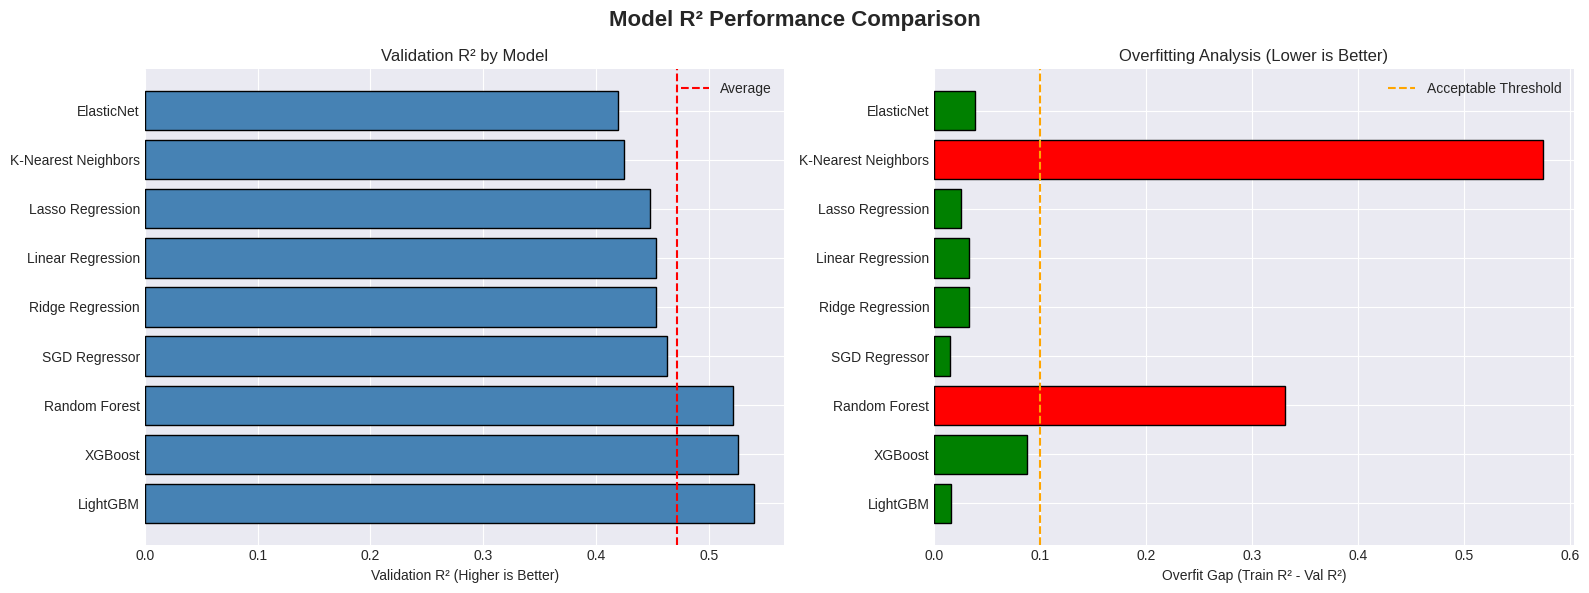


 BEST MODEL: LightGBM
   Validation R²: 0.5400


In [13]:
print("MODEL COMPARISON SUMMARY")
print("."*80 + "\n")

# Create results DataFrame 
results_df = pd.DataFrame(results).sort_values('Val_R2', ascending=False).reset_index(drop=True)

# Display leaderboard
print(results_df[['Model', 'Train_R2', 'Val_R2', 'Overfit_Gap']].to_string(index=False))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model R² Performance Comparison', fontsize=16, fontweight='bold')

# 1. Validation R² Score
axes[0].barh(results_df['Model'], results_df['Val_R2'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Validation R² (Higher is Better)')
axes[0].set_title('Validation R² by Model')
axes[0].axvline(results_df['Val_R2'].mean(), color='red', linestyle='--', label='Average')
axes[0].legend()

# 2. Overfitting Analysis (Train R² - Val R²)
colors = ['red' if x > 0.1 else 'green' for x in results_df['Overfit_Gap']]
axes[1].barh(results_df['Model'], results_df['Overfit_Gap'], color=colors, edgecolor='black')
axes[1].set_xlabel('Overfit Gap (Train R² - Val R²)')
axes[1].set_title('Overfitting Analysis (Lower is Better)')
axes[1].axvline(0.1, color='orange', linestyle='--', label='Acceptable Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Identify best model
best_model = results_df.iloc[0]
print(f"\n BEST MODEL: {best_model['Model']}")
print(f"   Validation R²: {best_model['Val_R2']:.4f}")


## 9.Hyperparameter Tuning: XGBoost & LightGBM

The tuning process uses:
- **Search Method**: RandomizedSearchCV with 20 iterations
- **Cross-Validation**: 3-fold CV
- **Scoring Metric**: R² (coefficient of determination)
- **Optimization**: Parallel processing with all available CPU cores

**XGBoost Parameters**
- `n_estimators`: [100, 200, 300]
- `max_depth`: [5, 7, 9]
- `learning_rate`: [0.01, 0.05, 0.1]
- `subsample`: [0.7, 0.8, 0.9]
- `colsample_bytree`: [0.7, 0.8, 0.9]

**LightGBM Parameters**
- `n_estimators`: [100, 200, 300]
- `max_depth`: [5, 7, 9, -1]
- `learning_rate`: [0.01, 0.05, 0.1]
- `num_leaves`: [31, 50, 70]
- `subsample`: [0.7, 0.8, 0.9]


In [14]:
print("Hyperparameter tuning: XGBoost & LightGBM")
print("."*80 + "\n")

# Define models and their parameter grids
models_to_tune = {
    'XGBoost': {
        'model': xgb.XGBRegressor(random_state=42),
        'param_grid': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [5, 7, 9],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__subsample': [0.7, 0.8, 0.9],
            'model__colsample_bytree': [0.7, 0.8, 0.9]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
        'param_grid': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [5, 7, 9, -1],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__num_leaves': [31, 50, 70],
            'model__subsample': [0.7, 0.8, 0.9]
        }
    }
}

tuned_results = []

# Loop over models
for name, info in models_to_tune.items():
    print(f"Tuning {name}")
    print("."*60)

    # Create pipeline 
    pipeline = Pipeline([
        ('model', info['model'])
    ])

    # Randomized Search
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=info['param_grid'],
        n_iter=20, cv=3,
        scoring='r2',
        random_state=42, n_jobs=-1, verbose=1
    )
    search.fit(X_train, y_train)

    # Predict and calculate R²
    y_val_pred = np.maximum(search.predict(X_val), 0)
    tuned_results.append({
        'Model': f'{name} (Tuned)',
        'Val_R2': r2_score(y_val, y_val_pred),
        'Best_Params': search.best_params_
    })

# Display results
tuned_df = pd.DataFrame(tuned_results)
print("\n" + "="*80)
print("HYPERPARAMETER TUNING RESULTS")
print("="*80 + "\n")
print(tuned_df[['Model', 'Val_R2']].to_string(index=False))


Hyperparameter tuning: XGBoost & LightGBM
................................................................................

Tuning XGBoost
............................................................
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning LightGBM
............................................................
Fitting 3 folds for each of 20 candidates, totalling 60 fits

HYPERPARAMETER TUNING RESULTS

           Model  Val_R2
 XGBoost (Tuned)    0.53
LightGBM (Tuned)    0.55


## 10. Test Set Preparation

The test set is prepered in the way match with the training dataset structure for prediction

**Steps included:**

1. Extract theater ID and show date from the sample submission ID.
2. Merge with date information and create temporal features.
3. Merge with theater information and handle missing values.
4. Merge online and POS booking features.
5. Create combined booking features (total tickets, online/POS ratio).
6. Generate lag features based on historical data.
7. Generate rolling window features based on historical data.
8. Merge theater-level aggregate features.
9. Encode categorical variables using label encoders from training.
10. Verify all features exist and create any missing ones.
11. Select final features in the same order as training.


In [15]:

# Step 0: Load sample submission
test_df = sample_submission[['ID']].copy()

# Extract theater ID and show date from ID
test_df['book_theater_id'] = test_df['ID'].apply(lambda x: '_'.join(x.split('_')[:2]))
test_df['show_date'] = pd.to_datetime(test_df['ID'].apply(lambda x: x.split('_')[2]))

print(f"Test set size: {len(test_df)} rows")
print(f"Date range: {test_df['show_date'].min().date()} to {test_df['show_date'].max().date()}\n")

# Step 1: Merge date info
test_df = test_df.merge(date_info_clean, on='show_date', how='left')

print ('Step 1 done')

# Step 2: Create date-based features
test_df['year'] = test_df['show_date'].dt.year
test_df['month'] = test_df['show_date'].dt.month
test_df['day'] = test_df['show_date'].dt.day
test_df['week_of_year'] = test_df['show_date'].dt.isocalendar().week.astype(int)
test_df['day_of_month'] = test_df['show_date'].dt.day
test_df['quarter'] = test_df['show_date'].dt.quarter
test_df['is_weekend'] = test_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

test_df['season'] = test_df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Mansoon', 7: 'Mansoon', 8: 'Mansoon',
    9: 'Mansoon', 10: 'Winter', 11: 'Winter'
})

print ('Step 2 done')

# Step 3: Merge theater info
test_df = test_df.merge(booknow_theaters_clean, on='book_theater_id', how='left')
test_df['is_theater_info_missing'] = test_df['theater_type'].isnull().astype(int)
test_df['theater_type'] = test_df['theater_type'].fillna('Unknown')
test_df['theater_area'] = test_df['theater_area'].fillna('Unknown')

# Drop coordinates if exist
if 'latitude' in test_df.columns:
    test_df = test_df.drop(columns=['latitude', 'longitude'])
    
print ('Step 3 done')
# Step 4: Merge online & POS booking features
test_df = test_df.merge(online_features, on=['book_theater_id', 'show_date'], how='left')
test_df = test_df.merge(pos_features, on=['book_theater_id', 'show_date'], how='left')

# Fill missing booking features with 0
booking_feature_cols = [
    'total_online_tickets', 'online_booking_count', 'avg_online_lead_days',
    'max_online_lead_days', 'min_online_lead_days',
    'total_pos_tickets', 'pos_transaction_count', 'avg_pos_tickets_per_transaction'
]
test_df[booking_feature_cols] = test_df[booking_feature_cols].fillna(0)
print ('Step 4 done')

# Step 5: Create combined booking features
test_df['total_tickets_all_channels'] = test_df['total_online_tickets'] + test_df['total_pos_tickets']
test_df['online_pos_ratio'] = np.where(
    test_df['total_pos_tickets'] > 0,
    test_df['total_online_tickets'] / test_df['total_pos_tickets'],
    0
)
print ('Step 5 done')

# Step 6: Create lag features
for lag in lag_periods:
    col_name = f'audience_lag_{lag}'
    last_values = master_df.groupby('book_theater_id')[col_name].last().reset_index()
    test_df = test_df.merge(last_values, on='book_theater_id', how='left', suffixes=('', '_new'))
    
    if f'{col_name}_new' in test_df.columns:
        test_df[col_name] = test_df[f'{col_name}_new']
        test_df.drop(columns=[f'{col_name}_new'], inplace=True)
    
    # Fill missing lag with median
    median_val = master_df[col_name].median() if col_name in master_df.columns else 0
    test_df[col_name] = test_df[col_name].fillna(median_val)

print ('Step 6 done')

# Step 7: Create rolling window features
for window in windows:
    for stat in ['mean', 'std']:
        col_name = f'audience_rolling_{stat}_{window}'
        last_values = master_df.groupby('book_theater_id')[col_name].last().reset_index()
        test_df = test_df.merge(last_values, on='book_theater_id', how='left', suffixes=('', '_new'))
        
        if f'{col_name}_new' in test_df.columns:
            test_df[col_name] = test_df[f'{col_name}_new']
            test_df.drop(columns=[f'{col_name}_new'], inplace=True)
        
        # Fill missing rolling values
        median_val = master_df[col_name].median() if col_name in master_df.columns else 0
        test_df[col_name] = test_df[col_name].fillna(median_val)

print ('Step 7 done')

# Step 8: Merge theater-level aggregates
if 'theater_stats' in globals():
    test_df = test_df.merge(theater_stats, on='book_theater_id', how='left', suffixes=('', '_new'))
    for col in ['theater_avg_audience','theater_std_audience','theater_median_audience','theater_total_shows']:
        if f'{col}_new' in test_df.columns:
            test_df[col] = test_df[f'{col}_new']
            test_df.drop(columns=[f'{col}_new'], inplace=True)
        # Fill missing values
        test_df[col] = test_df[col].fillna(master_df[col].mean() if col != 'theater_total_shows' else 0)

print ('Step 8 done')

# Step 9: Encode categorical variables
for col, le in label_encoders.items():
    if col in test_df.columns:
        test_df[col] = test_df[col].astype(str).map(lambda x: x if x in le.classes_ else 'Unknown')
        if 'Unknown' not in le.classes_:
            le.classes_ = np.append(le.classes_, 'Unknown')
        test_df[col] = le.transform(test_df[col])

print ('Step 9 done')

# Step 10: Verify feature alignment
missing_features = [col for col in feature_cols if col not in test_df.columns]
for feat in missing_features:
    test_df[feat] = 0  # default value

print ('Step 10 done')

# Step 11: Select final features in the same order as training
X_test = test_df[feature_cols]

print ('Step 10 done')
print(f"Test features prepared: {X_test.shape}")

Test set size: 38062 rows
Date range: 2024-03-01 to 2024-04-22

Step 1 done
Step 2 done
Step 3 done
Step 4 done
Step 5 done
Step 6 done
Step 7 done
Step 8 done
Step 9 done
Step 10 done
Step 10 done
Test features prepared: (38062, 36)


# 11.Final Model Selection and Training

- Select the final best model based on **hyperparameter tuning results** (or baseline if no tuning).  
- Retrain the selected model on the **full training dataset** (training + validation) to maximize learning.  
- This final model will be used for **test predictions or deployment**.


In [16]:
# FINAL MODEL, PREDICTIONS & SUBMISSION
#........................................
# Select best model from tuning results
best_row = tuned_df.loc[tuned_df['Val_R2'].idxmax()]
best_model_name = best_row['Model']
best_params = best_row['Best_Params']

from lightgbm import LGBMRegressor
final_model = LGBMRegressor(
    n_estimators=best_params['model__n_estimators'],
    max_depth=best_params['model__max_depth'],
    learning_rate=best_params['model__learning_rate'],
    num_leaves=best_params.get('model__num_leaves', 31),
    subsample=best_params.get('model__subsample', 1.0),
    random_state=42,
    verbose=-1
)

print(f"BEST MODEL: {best_model_name}")
print(f"Estimator: {final_model}\n")

# Train on full data (train + validation)
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
final_model.fit(X_full, y_full)

# Predict on test set
preds = np.round(np.maximum(final_model.predict(X_test), 0)).astype(int)
print(f"Predictions generated for {len(preds)} samples")

# Create submission file
submission = pd.DataFrame({'ID': test_df['ID'], 'audience_count': preds})
submission.to_csv('submission.csv', index=False)
print("SUBMISSION FILE CREATED: submission.csv")

# Preview and statistics
print("\nPreview:\n", submission.head(10))
print("\nStatistics:\n", submission['audience_count'].describe())


BEST MODEL: LightGBM (Tuned)
Estimator: LGBMRegressor(learning_rate=0.05, num_leaves=70, random_state=42, subsample=0.8,
              verbose=-1)

Predictions generated for 38062 samples
SUBMISSION FILE CREATED: submission.csv

Preview:
                       ID  audience_count
0  book_00001_2024-03-01              37
1  book_00001_2024-03-02              44
2  book_00001_2024-03-03              51
3  book_00001_2024-03-04              40
4  book_00001_2024-03-06              32
5  book_00001_2024-03-07              35
6  book_00001_2024-03-08              37
7  book_00001_2024-03-09              45
8  book_00001_2024-03-10              51
9  book_00001_2024-03-11              42

Statistics:
 count   38062.00
mean       40.07
std        21.61
min         7.00
25%        23.00
50%        36.00
75%        53.00
max       163.00
Name: audience_count, dtype: float64
